# 04 · Équivalence avec `HierarchicalForecast` et origine de l'écart

**Bloc 2 · W37, notebook 4 sur 4.** On compare l'implémentation maison à
`MinTrace(method="mint_shrink")`, puis on explique l'écart résiduel.

> Critère du plan : écart relatif **< 1e-3**, et **non nul**. *Si tu obtiens 0 exact, tu as recopié leur code.*

In [1]:
import warnings; warnings.filterwarnings("ignore")
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display, Markdown

from w37_reconciliation import viz
from w37_reconciliation.data import build_hierarchy, make_region_channel_data, train_test_split, to_wide
from w37_reconciliation.forecasting import fit_base_forecasts, residual_matrix

viz.setup()
pd.set_option("display.precision", 3)
np.set_printoptions(precision=3, suppress=True)

In [2]:
from w37_reconciliation.mint.experiment import run_mint_experiment, gap_decomposition, m_greater_than_T_demo
from w37_reconciliation.pipeline import mase
exp = run_mint_experiment()
order, labels, S = exp.hierarchy.order, viz.short(exp.hierarchy.order), exp.hierarchy.S

## 1. Les critères « c'est fini quand… »

In [3]:
mt = exp.metrics
crit = pd.DataFrame([
    ("SGS − S nul", "< 1e-12", mt["unbiasedness"], mt["unbiasedness"] < 1e-12),
    ("incohérence des prévisions réconciliées", "< 1e-9", mt["incoherence"], mt["incoherence"] < 1e-9),
    ("écart relatif à la bibliothèque", "< 1e-3", mt["relative_gap"], mt["relative_gap"] < 1e-3),
    ("écart non nul (pas de copie)", "> 0", mt["absolute_gap"], mt["absolute_gap"] > 0),
], columns=["critère", "seuil", "mesuré", "OK"])
display(crit.style.format({"mesuré": "{:.2e}"}))
print(f"λ = {mt['lambda']:.6f} | T = {mt['T']} | niveau moyen des valeurs ≈ {mt['mean_level']:.0f}")

,critère,seuil,mesuré,OK
0,SGS − S nul,< 1e-12,2.22e-16,True
1,incohérence des prévisions réconciliées,< 1e-9,5.68e-14,True
2,écart relatif à la bibliothèque,< 1e-3,1.07e-05,True
3,écart non nul (pas de copie),> 0,1.77e-03,True


λ = 0.113325 | T = 72 | niveau moyen des valeurs ≈ 165


## 2. Où se trouve l'écart ?

On affiche, pour chaque série et chaque horizon, la différence entre mon résultat et celui de la bibliothèque. Elle
reste de l'ordre du millième d'unité, sur des valeurs autour de 165.

findfont: Failed to find font weight semibold for DejaVu Sans, now using 700.


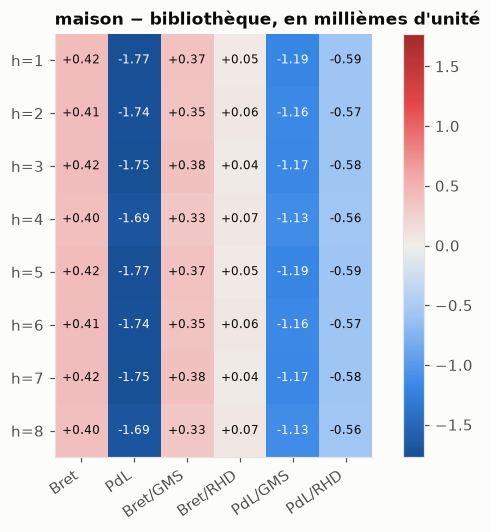

In [4]:
diff = (exp.mine - exp.lib) * 1e3                 # en millièmes d'unité
fig, ax = plt.subplots(figsize=(9, 5))
viz.heatmap(ax, diff, labels_x=labels, labels_y=[f"h={k + 1}" for k in range(diff.shape[0])],
            diverging=True, fmt="{:+.2f}", title="maison − bibliothèque, en millièmes d'unité")
plt.show()

## 3. Pourquoi l'écart n'est pas nul : une décomposition

Le plan l'attribue à *« l'estimateur de λ, qui diffère d'une implémentation à l'autre »*. On teste cette hypothèse
en isolant les deux ingrédients de $W$ :

1. **la covariance de base** : $E'E/T$ (non centrée, squelette du plan) ou `np.cov` (centrée, ddof = 1) ;
2. **λ**, estimé sur résidus non centrés ou centrés.

Pour chaque combinaison, on recalcule la réconciliation et on mesure l'écart absolu maximal à la bibliothèque.

In [5]:
dec = gap_decomposition(exp)
display(dec.style.format({"λ": "{:.6f}", "écart absolu": "{:.2e}"}))

,covariance de base,λ estimé sur résidus,λ,écart absolu
0,E'E/T (plan),non centré,0.113325,1.77e-03
1,"np.cov, ddof=1 (lib)",non centré,0.113325,3.26e-06
2,"np.cov, ddof=1 (lib)",centré,0.116517,4.54e-04


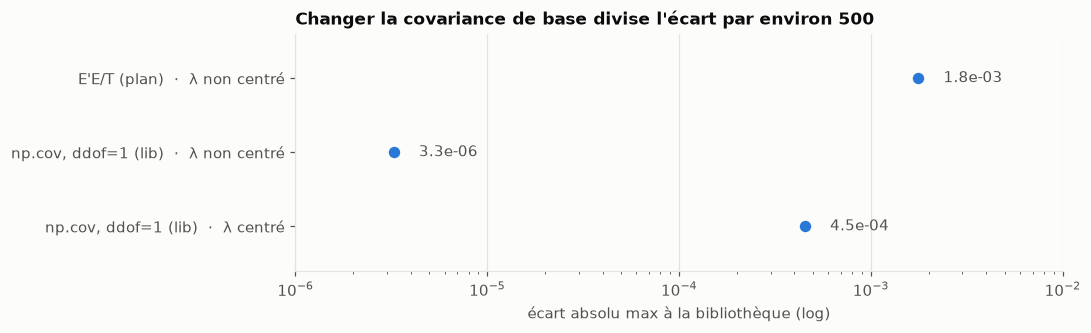

In [6]:
fig, ax = plt.subplots(figsize=(9, 2.8))
lbl = (dec["covariance de base"] + "  ·  λ " + dec["λ estimé sur résidus"])[::-1].tolist()
vals = dec["écart absolu"][::-1].to_numpy()
ax.scatter(vals, lbl, s=90, color=viz.BLUE, zorder=3, edgecolor=viz.SURFACE, linewidth=2)
for i, v in enumerate(vals):
    ax.text(v * 1.35, i, f"{v:.1e}", va="center", color=viz.TEXT_2)
ax.set_xscale("log"); ax.set_xlim(1e-6, 1e-2); ax.set_ylim(-0.6, 2.6); ax.grid(axis="y", visible=False)
ax.set_xlabel("écart absolu max à la bibliothèque (log)")
ax.set_title("Changer la covariance de base divise l'écart par environ 500")
plt.show()

**Conclusion.**

- **≈ 99,8 % de l'écart vient de la covariance de base.** `HierarchicalForecast` utilise `np.cov`, donc des résidus
  centrés et une division par T − 1. Avec la même base, l'écart tombe de 1,8e-3 à **3,3e-6**.
- **L'écart qui reste (≈ 0,2 %) vient bien de λ**, mais il est minuscule : 0,113325 chez moi contre 0,113303 pour
  la bibliothèque.
- La bibliothèque estime λ sur des résidus **non centrés**. Si on centre aussi pour λ, l'écart **remonte** à 4,5e-4.

On peut le vérifier directement sur la matrice $W$ de la bibliothèque :

In [7]:
from hierarchicalforecast.utils import _shrunk_covariance_schaferstrimmer_no_nans as lib_shrunk
W_lib = lib_shrunk(np.ascontiguousarray(exp.E.T), 2e-8)
C = np.cov(exp.E.T); d = np.sqrt(np.diag(C)); off = ~np.eye(len(C), dtype=bool)
lam_lib = 1 - ((W_lib / np.outer(d, d))[off] / (C / np.outer(d, d))[off]).mean()
display(pd.DataFrame({
    "hypothèse sur la base": ["E'E/T (plan)", "np.cov (centrée, ddof=1)"],
    "max |diag − diag(W_lib)|": [np.abs(np.diag(exp.cov.W1) - np.diag(W_lib)).max(), np.abs(np.diag(C) - np.diag(W_lib)).max()],
}).style.format({"max |diag − diag(W_lib)|": "{:.1e}"}))
print(f"λ bibliothèque = {lam_lib:.6f}   |   λ maison = {exp.cov.lam:.6f}")

,hypothèse sur la base,max |diag − diag(W_lib)|
0,E'E/T (plan),3.8e-02
1,"np.cov (centrée, ddof=1)",8.9e-16


λ bibliothèque = 0.113303   |   λ maison = 0.113325


## 4. Ce que la réconciliation change à la précision

Ce n'est pas l'objet du bloc 2, mais c'est la question qu'un client posera. On calcule le MASE sur les 8
trimestres de test, par niveau, pour les prévisions de base et pour trois réconciliations.

In [8]:
y_true = to_wide(exp.test, order).to_numpy(); y_train = to_wide(exp.train, order).to_numpy()
methods = {"base (incohérente)": exp.y_hat,
           "BottomUp": to_wide(exp.Y_rec, order, "AutoETS/BottomUp").to_numpy(),
           "OLS": to_wide(exp.Y_rec, order, "AutoETS/MinTrace_method-ols").to_numpy(),
           "MinT(shrink) maison": exp.mine}
lv = {"région": [0, 1], "feuille": [2, 3, 4, 5]}
tab = pd.DataFrame({name: {k: mase(y_true, yh, y_train, 4)[idx].mean() for k, idx in lv.items()}
                    for name, yh in methods.items()}).T
display(tab.style.format("{:.4f}"))

,région,feuille
base (incohérente),1.1371,1.1794
BottomUp,1.1368,1.1794
OLS,1.1370,1.1734
MinT(shrink) maison,1.1374,1.1718


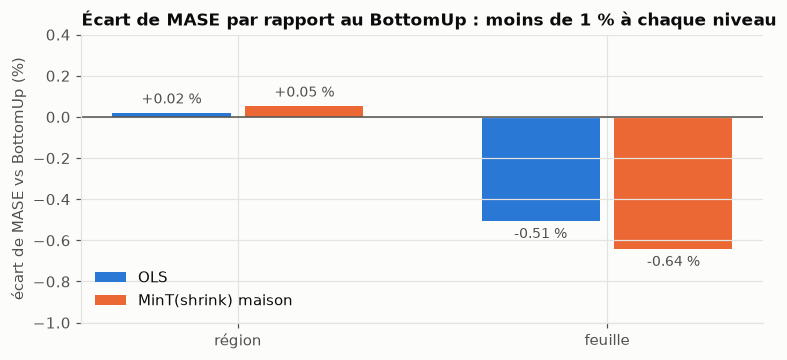

In [9]:
delta = (tab.loc[["OLS", "MinT(shrink) maison"]] / tab.loc["BottomUp"] - 1) * 100
fig, ax = plt.subplots(figsize=(8, 3.4))
x = np.arange(len(lv)); w = 0.36
for k, (name, color) in enumerate(zip(delta.index, viz.SERIES)):
    ax.bar(x + (k - 0.5) * w, delta.loc[name], width=w - 0.04, color=color, label=name)
    for xi, v in zip(x, delta.loc[name]):
        ax.text(xi + (k - 0.5) * w, v + (0.03 if v >= 0 else -0.03), f"{v:+.2f} %", ha="center",
                va="bottom" if v >= 0 else "top", color=viz.TEXT_2, fontsize=9)
ax.axhline(0, color=viz.TEXT_2, lw=1)
ax.set_xticks(x, list(lv)); ax.set_ylabel("écart de MASE vs BottomUp (%)")
ax.set_ylim(-1, 0.4)
ax.set_title("Écart de MASE par rapport au BottomUp : moins de 1 % à chaque niveau")
ax.legend(loc="lower left")
plt.show()

**Lecture honnête.** Sur ce jeu synthétique, les feuilles sont indépendantes et toutes bien modélisées par
AutoETS. Les trois réconciliations restent à moins de 1 % les unes des autres. C'est l'argument du bloc 1 :
**la réconciliation garantit la cohérence, pas la précision.** Le graphique montre l'écart **relatif** au BottomUp, la
vraie baseline de réconciliation ; une valeur négative signifie que la méthode fait mieux que le BottomUp. Le mini-projet éCO2mix (bloc 5) dira ce qu'il en est sur données réelles.

## 5. Récapitulatif du bloc 2

| Livrable | Où |
|---|---|
| Shrinkage Schäfer–Strimmer écrit de zéro | `src/w37_reconciliation/mint/shrinkage.py` |
| $G$ et $P$ | `src/w37_reconciliation/mint/projection.py` |
| Les 3 assertions | `src/w37_reconciliation/mint/checks.py` ; `uv run w37 mint` |
| Tests | `tests/unit/test_shrinkage.py`, `tests/unit/test_projection.py`, `tests/integration/test_mint_vs_library.py` |